# Modul 2 — Python pentru Geoscience
**DELTA-Hub Workshop · 22 mai 2026 · 11:45–13:00**

Parcurgem patru etape:

| Etapă | Ce învățăm | Minute |
|:---:|:---|:---:|
| 1 | **Python de la zero** — variabile, liste, dicționare, funcții | 0–20 |
| 2 | **Geodate** — coordonate, CRS, raster vs vector | 20–45 |
| 3 | **Formate de fișiere** — GeoJSON, GPKG, NetCDF, GeoTIFF, Zarr | 45–65 |
| 4 | **Vizualizare** — matplotlib recap + Plotly interactiv | 65–75 |
| — | Exercițiu | 75–80 |

Nu presupunem nicio cunoștință anterioară de Python.

In [30]:
#!pip install -q numpy pandas geopandas xarray rioxarray netCDF4 pyproj matplotlib shapely zarr plotly
#import warnings; warnings.filterwarnings('ignore')
#print('✓ Pachete instalate.')

---
## Biblioteci folosite în acest modul

Înainte să scriem cod, prezentăm instrumentele. Fiecare `import` aduce o bibliotecă cu un scop specific.

| Import | Aliasul | Ce face |
|:---|:---:|:---|
| `import math` | — | Matematică de bază din Python standard: `sqrt`, `cos`, `radians` |
| `import numpy as np` | `np` | Array-uri numerice N-dimensionale, operații vectorizate, statistici |
| `import pandas as pd` | `pd` | Tabele cu etichete (DataFrame), serii temporale, citit/scris CSV |
| `import matplotlib.pyplot as plt` | `plt` | Grafice 2D **statice**: linii, bare, hărți raster, scatter — ideal pentru publicații |
| `import plotly.express as px` | `px` | Grafice **interactive** HTML: line, bar, imshow, scatter_mapbox — hover și zoom inclus |
| `import geopandas as gpd` | `gpd` | Date **vectoriale** geospațiale — extinde pandas cu coloana `geometry` |
| `from shapely.geometry import Point` | — | Creează geometrii discrete: `Point`, `LineString`, `Polygon` |
| `from pyproj import Transformer` | — | Conversii precise între sisteme de coordonate (CRS) |
| `import xarray as xr` | `xr` | Array-uri N-dimensionale cu **etichete** pe dimensiuni (`time`, `lat`, `lon`) — ideal pentru NetCDF și Zarr |
| `import rioxarray` | — | Extinde xarray cu operații **raster**: CRS, clip, reproject, citit/scris GeoTIFF |

> **Convenție:** aliasurile (`np`, `pd`, `plt`, `gpd`, `xr`, `px`) sunt standarde în comunitate — le vei vedea în orice tutorial sau documentație.

---
# Etapa 1 · Python de la zero
## 1.1 Variabile și tipuri

In [31]:
# ── Tipuri de date de bază ────────────────────────────────────────────
latitudine   = 45.15        # float  — număr cu virgulă
longitudine  = 29.65        # float
altitudine   = 0            # int    — număr întreg
localitate   = 'Sulina'     # str    — text (șir de caractere)
are_date_gps = True         # bool   — True / False

print(type(latitudine))      # <class 'float'>
print(type(localitate))      # <class 'str'>

# f-string: interpolezi variabile în text cu {}
print(f'{localitate}: {latitudine}°N, {longitudine}°E, {altitudine} m altitudine')

# Operații aritmetice
temp_celsius = 22.5
temp_kelvin  = temp_celsius + 273.15
print(f'{temp_celsius}°C  =  {temp_kelvin} K')

<class 'float'>
<class 'str'>
Sulina: 45.15°N, 29.65°E, 0 m altitudine
22.5°C  =  295.65 K


## 1.2 Liste

In [32]:
# ── Liste — colecții ordonate ─────────────────────────────────────────
statii = ['Sulina', 'Sf. Gheorghe', 'Crișan', 'Maliuc', 'Chilia Veche']

print('Prima stație :', statii[0])    # index din 0
print('Ultima stație:', statii[-1])   # index negativ = de la sfârșit
print('Slice [1:3]  :', statii[1:3])  # de la 1 (inclus) la 3 (exclus)
print('Lungime      :', len(statii))

# Modificare
statii.append('Sf. Gheorghe Nou')     # adaugă la final
print('\nDupă append  :', statii)

# Tipuri mixte — o listă poate conține orice
info_sulina = ['Sulina', 45.15, 29.65, True, 3200]
print('\nInfo Sulina  :', info_sulina)

Prima stație : Sulina
Ultima stație: Chilia Veche
Slice [1:3]  : ['Sf. Gheorghe', 'Crișan']
Lungime      : 5

După append  : ['Sulina', 'Sf. Gheorghe', 'Crișan', 'Maliuc', 'Chilia Veche', 'Sf. Gheorghe Nou']

Info Sulina  : ['Sulina', 45.15, 29.65, True, 3200]


## 1.3 Dicționare

In [33]:
# ── Dicționar — perechi cheie: valoare ───────────────────────────────
sulina = {
    'name'      : 'Sulina',
    'lat'       : 45.15,
    'lon'       : 29.65,
    'tip'       : 'port',
    'populatie' : 3200,
}

print(sulina['name'])               # accesare după cheie
print(f"Pop: {sulina['populatie']} locuitori")

# Dicționar de dicționare — util pentru seturi de stații
statii_info = {
    'Sulina'      : {'lat': 45.15, 'lon': 29.65, 'pop': 3200},
    'Sf. Gheorghe': {'lat': 44.90, 'lon': 29.60, 'pop':  800},
    'Crișan'      : {'lat': 45.02, 'lon': 29.42, 'pop':  250},
}

print('\nStații disponibile:', list(statii_info.keys()))
print('Date Crișan       :', statii_info['Crișan'])

Sulina
Pop: 3200 locuitori

Stații disponibile: ['Sulina', 'Sf. Gheorghe', 'Crișan']
Date Crișan       : {'lat': 45.02, 'lon': 29.42, 'pop': 250}


## 1.4 Bucle și condiții

In [34]:
# ── for + if/elif/else ────────────────────────────────────────────────
temperaturi = [22.3, 18.5, 25.1, 30.4, 15.0, 28.7]

for t in temperaturi:
    if t >= 28:
        categorie = '🔴 caniculă'
    elif t >= 22:
        categorie = '🟡 cald'
    else:
        categorie = '🔵 răcoros'
    print(f'  {t:5.1f}°C  →  {categorie}')

# enumerate: indice + valoare simultan
print()
for i, (statie, info) in enumerate(statii_info.items()):
    print(f'  {i+1}. {statie:<15s}  {info["lat"]}°N  {info["lon"]}°E')

# List comprehension — versiune compactă a unui for
zile_calde = [t for t in temperaturi if t >= 28]
print(f'\nZile cu caniculă: {len(zile_calde)} ({zile_calde})')

   22.3°C  →  🟡 cald
   18.5°C  →  🔵 răcoros
   25.1°C  →  🟡 cald
   30.4°C  →  🔴 caniculă
   15.0°C  →  🔵 răcoros
   28.7°C  →  🔴 caniculă

  1. Sulina           45.15°N  29.65°E
  2. Sf. Gheorghe     44.9°N  29.6°E
  3. Crișan           45.02°N  29.42°E

Zile cu caniculă: 2 ([30.4, 28.7])


## 1.5 Funcții

In [35]:
# ── def — definirea unei funcții ─────────────────────────────────────
def categorie_temp(t_celsius):
    """Clasifică temperatura în: răcoros / cald / caniculă."""
    if t_celsius >= 28:
        return 'caniculă'
    elif t_celsius >= 22:
        return 'cald'
    else:
        return 'răcoros'

# Apel simplu
print(categorie_temp(25.5))    # cald
print(categorie_temp(14.0))    # răcoros

# Parametru cu valoare implicită
def descrie_statie(name, lat, lon, tip='necunoscut'):
    hem_lat = 'N' if lat >= 0 else 'S'
    hem_lon = 'E' if lon >= 0 else 'V'
    return f"{name} ({tip}): {abs(lat):.2f}°{hem_lat}, {abs(lon):.2f}°{hem_lon}"

print()
for statie, info in statii_info.items():
    print(descrie_statie(statie, info['lat'], info['lon'], 'sat'))

cald
răcoros

Sulina (sat): 45.15°N, 29.65°E
Sf. Gheorghe (sat): 44.90°N, 29.60°E
Crișan (sat): 45.02°N, 29.42°E


## 1.6 NumPy — calcul numeric rapid

In [36]:
lista_t = [22.3, 18.5, 25.1, 30.4, 15.0, 28.7, 21.2, 19.8]

In [37]:
import numpy as np

# ── Array vs listă Python ─────────────────────────────────────────────
lista_t = [22.3, 18.5, 25.1, 30.4, 15.0, 28.7, 21.2, 19.8]
arr_t   = np.array(lista_t)      # conversie la array NumPy

# Operații pe întreg array-ul — nu nevoie de loop
print('Original  :', arr_t)
print('+2°C      :', arr_t + 2)          # broadcasting scalar
print('°C → °F   :', arr_t * 9/5 + 32)  # conversie vectorizată

# Statistici
print(f'\nMedie : {np.mean(arr_t):.2f}°C')
print(f'Max   : {np.max(arr_t):.2f}°C  (index {np.argmax(arr_t)})')
print(f'Min   : {np.min(arr_t):.2f}°C')
print(f'Std   : {np.std(arr_t):.2f}°C')

# Indexare logică
print(f'\nZile  > 25°C : {arr_t[arr_t > 25]}')
print(f'Număr zile   : {np.sum(arr_t > 25)}')

Original  : [22.3 18.5 25.1 30.4 15.  28.7 21.2 19.8]
+2°C      : [24.3 20.5 27.1 32.4 17.  30.7 23.2 21.8]
°C → °F   : [72.14 65.3  77.18 86.72 59.   83.66 70.16 67.64]

Medie : 22.62°C
Max   : 30.40°C  (index 3)
Min   : 15.00°C
Std   : 4.86°C

Zile  > 25°C : [25.1 30.4 28.7]
Număr zile   : 3


Shape: (5, 6)  →  5 rânduri × 6 coloane
Colț stânga-sus [0,0]: 20.1°C
Colț dreapta-jos      : 25.0°C
Rândul 2 (index 2)    : [21.5 22.  22.5 23.  23.2 23.5]
Medie întreagă grilă  : 22.52°C


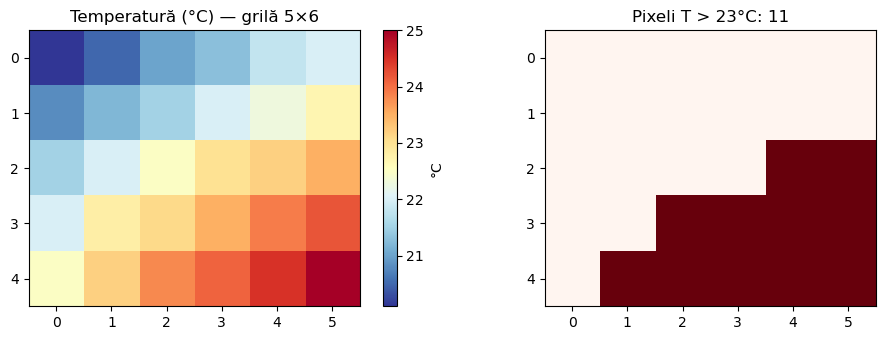

In [38]:
import matplotlib.pyplot as plt

# ── Array 2D = grilă = raster ─────────────────────────────────────────
# Temperatura de suprafață (°C) pe o grilă mică 5×6 — imaginează-ți o hartă
grila_temp = np.array([
    [20.1, 20.5, 21.0, 21.3, 21.8, 22.0],
    [20.8, 21.2, 21.5, 22.0, 22.3, 22.7],
    [21.5, 22.0, 22.5, 23.0, 23.2, 23.5],
    [22.0, 22.8, 23.1, 23.5, 23.9, 24.2],
    [22.5, 23.2, 23.8, 24.1, 24.5, 25.0],
])

print(f'Shape: {grila_temp.shape}  →  {grila_temp.shape[0]} rânduri × {grila_temp.shape[1]} coloane')
print(f'Colț stânga-sus [0,0]: {grila_temp[0,0]}°C')
print(f'Colț dreapta-jos      : {grila_temp[-1,-1]}°C')
print(f'Rândul 2 (index 2)    : {grila_temp[2,:]}')
print(f'Medie întreagă grilă  : {np.mean(grila_temp):.2f}°C')

# Vizualizare rapidă
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
im = axes[0].imshow(grila_temp, cmap='RdYlBu_r', origin='upper')
axes[0].set_title('Temperatură (°C) — grilă 5×6')
plt.colorbar(im, ax=axes[0], label='°C')

# Mascare: pixeli cu T > 23°C
mask_cald = grila_temp > 23.0
axes[1].imshow(mask_cald.astype(int), cmap='Reds', origin='upper')
axes[1].set_title(f'Pixeli T > 23°C: {mask_cald.sum()}')

plt.tight_layout()
plt.show()

---
# Etapa 2 · Geodate — coordonate, CRS, raster vs vector

## 2.1 Ce este un sistem de coordonate?

Orice dată geospațială are nevoie de un **CRS (Coordinate Reference System)** — un set de reguli care definesc cum se mapează un punct de pe Pământ la o pereche de numere.

Există două tipuri mari:

| Tip | Unitate | Avantaj | Exemple |
|:---|:---|:---|:---|
| **Geografic** | grade (°) | global, simplu | EPSG:4326 — lat/lon WGS84 |
| **Proiectat** | metri (m) | distanțe, arii exacte | EPSG:32635 — UTM Zona 35N |

> **Regula de aur:** înainte de orice analiză, verifică CRS-ul datelor tale. Date în CRS diferite nu se pot combina direct.

In [39]:
import math

# ── EPSG:4326 — coordonate geografice (lat/lon) ───────────────────────
# Lat/lon sunt unghiuri față de Ecuator și Meridianul Greenwich
#   lat: −90° (Pol Sud) → +90° (Pol Nord)
#   lon: −180° (V) → +180° (E)

puncte = {
    'Sulina'      : (45.15, 29.65),
    'Sf. Gheorghe': (44.90, 29.60),
    'Crișan'      : (45.02, 29.42),
    'Maliuc'      : (45.12, 29.38),
}

# Problemă cu gradele: 1° longitudine ≠ aceeași distanță la orice latitudine
lat_ref = 45.0
km_lat  = 111.0                                     # ≈ constant
km_lon  = 111.0 * math.cos(math.radians(lat_ref))   # scade spre poli

print(f'La {lat_ref}°N:')
print(f'  1° latitudine  ≈ {km_lat:.1f} km')
print(f'  1° longitudine ≈ {km_lon:.1f} km  ← NU egal!')

# Calcul distanță aproximativă în grade (nu recomandat pentru analize)
def dist_grade(p1, p2):
    dlat = (p1[0] - p2[0]) * km_lat
    dlon = (p1[1] - p2[1]) * km_lon
    return math.sqrt(dlat**2 + dlon**2)

d = dist_grade(puncte['Sulina'], puncte['Sf. Gheorghe'])
print(f'\nSulina → Sf. Gheorghe (aprox. din grade): {d:.1f} km')

La 45.0°N:
  1° latitudine  ≈ 111.0 km
  1° longitudine ≈ 78.5 km  ← NU egal!

Sulina → Sf. Gheorghe (aprox. din grade): 28.0 km


In [40]:
from pyproj import Transformer

# ── EPSG:32635 — UTM Zona 35N (coordonate proiectate) ────────────────
# x = Easting  (metri față de meridianul central al zonei, ~27°E)
# y = Northing (metri față de Ecuator)
#
# Avantaj: distanțele și ariile sunt EXACTE, calculate cu Pitagora

# Transformare lat/lon → UTM 35N
# always_xy=True: inputul e (lon, lat) nu (lat, lon)
t = Transformer.from_crs('EPSG:4326', 'EPSG:32635', always_xy=True)

print('Coordonate UTM 35N (Easting, Northing):')
puncte_utm = {}

for statie, (lat, lon) in puncte.items():
    x, y = t.transform(lon, lat)
    puncte_utm[statie] = (x, y)
    print(f'  {statie:<15s}  E={x:,.0f} m   N={y:,.0f} m')

# Distanță exactă în metri cu Pitagora
def dist_utm(p1_utm, p2_utm):
    return math.sqrt((p1_utm[0]-p2_utm[0])**2 + (p1_utm[1]-p2_utm[1])**2)

d_m = dist_utm(puncte_utm['Sulina'], puncte_utm['Sf. Gheorghe'])
print(f'\nSulina → Sf. Gheorghe (UTM, exact): {d_m/1000:.1f} km')

Coordonate UTM 35N (Easting, Northing):
  Sulina           E=708,315 m   N=5,003,030 m
  Sf. Gheorghe     E=705,276 m   N=4,975,131 m
  Crișan           E=690,667 m   N=4,988,021 m
  Maliuc           E=687,188 m   N=4,999,037 m

Sulina → Sf. Gheorghe (UTM, exact): 28.1 km


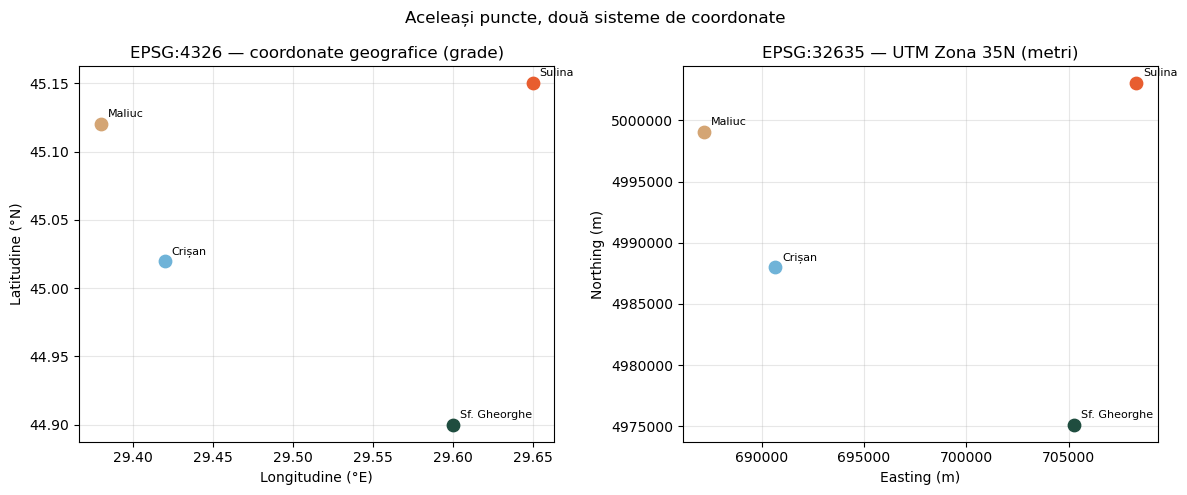

In [41]:
# ── Vizualizare: aceleași puncte în EPSG:4326 și EPSG:32635 ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

culori  = ['#E85D2F', '#1F4D3F', '#6FB3D8', '#D4A574']
statii_list = list(puncte.keys())

# EPSG:4326 — grade
for i, statie in enumerate(statii_list):
    lat, lon = puncte[statie]
    axes[0].scatter(lon, lat, color=culori[i], s=80, zorder=5)
    axes[0].annotate(statie, (lon, lat), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)
axes[0].set_title('EPSG:4326 — coordonate geografice (grade)')
axes[0].set_xlabel('Longitudine (°E)')
axes[0].set_ylabel('Latitudine (°N)')
axes[0].grid(alpha=0.3)

# EPSG:32635 — metri
for i, statie in enumerate(statii_list):
    x, y = puncte_utm[statie]
    axes[1].scatter(x, y, color=culori[i], s=80, zorder=5)
    axes[1].annotate(statie, (x, y), textcoords='offset points',
                     xytext=(5, 5), fontsize=8)
axes[1].set_title('EPSG:32635 — UTM Zona 35N (metri)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].ticklabel_format(style='plain')
axes[1].grid(alpha=0.3)

plt.suptitle('Aceleași puncte, două sisteme de coordonate', fontsize=12)
plt.tight_layout()
plt.show()

## 2.2 Raster vs Vector

Datele geospațiale se împart în două categorii:

| | **Raster** | **Vector** |
|:---|:---|:---|
| **Structură** | Grilă de pixeli | Geometrii (punct, linie, poligon) |
| **Exemple** | Imagini satelitare, DEM, temperaturi | Stații, râuri, granițe |
| **Formate** | GeoTIFF, NetCDF | GeoJSON, GPKG, Shapefile |
| **Bibliotecă Python** | xarray + rioxarray | geopandas |
| **CRS** | Scris în fișier (header) | Scris în fișier sau `.prj` |

In [42]:
import numpy as np

# ── Raster: o grilă regulată cu coordonate ───────────────────────────
# Definim o grilă de temperaturi pentru Delta Dunării
# Rezoluție: 0.1° × 0.1° (aprox. 11 km)

lats = np.arange(44.5, 45.6, 0.1)   # 11 valori N–S
lons = np.arange(28.8, 30.3, 0.1)   # 15 valori V–E

# Grid 2D de temperaturi — de vară, cresc spre est
rng  = np.random.default_rng(42)
grid = 22.0 + lons[np.newaxis, :] * 0.3 + rng.normal(0, 0.5, (len(lats), len(lons)))

print(f'Grilă raster: {grid.shape}  ({len(lats)} lat × {len(lons)} lon)')
print(f'Latitudini  : {lats[0]:.1f}°N → {lats[-1]:.1f}°N  (pas {lats[1]-lats[0]:.1f}°)')
print(f'Longitudini : {lons[0]:.1f}°E → {lons[-1]:.1f}°E')
print(f'T medie grilă: {np.mean(grid):.2f}°C')

# ── Vector: o tabelă cu geometrii ────────────────────────────────────
# Datele vectoriale sunt ca un tabel cu o coloană specială: geometria
print('\nVector (stații de măsurare):')
for statie, (lat, lon) in puncte.items():
    print(f'  {statie:<15s}  POINT({lon}, {lat})')

Grilă raster: (12, 15)  (12 lat × 15 lon)
Latitudini  : 44.5°N → 45.6°N  (pas 0.1°)
Longitudini : 28.8°E → 30.2°E
T medie grilă: 30.82°C

Vector (stații de măsurare):
  Sulina           POINT(29.65, 45.15)
  Sf. Gheorghe     POINT(29.6, 44.9)
  Crișan           POINT(29.42, 45.02)
  Maliuc           POINT(29.38, 45.12)


---
# Etapa 3 · Formate de fișiere
*(45–65 min)*

| Format | Tip | Când îl folosești |
|:---|:---:|:---|
| **GeoJSON** | Vector | Date mici (< 50 MB), partajare, web |
| **GPKG** | Vector | Producție, baze de date locale |
| **NetCDF** | Raster | Date climatice multidimensionale — ERA5, CMIP6, serii temporale |
| **GeoTIFF** | Raster | Un singur câmp 2D cu CRS, compatibil cu orice GIS |
| **Zarr** | Raster | Date foarte mari, cloud-native, acces chunked eficient |

## 3.1 GeoJSON și GPKG

In [43]:
import geopandas as gpd
from shapely.geometry import Point

# ── Creăm un GeoDataFrame ─────────────────────────────────────────────
# Un GeoDataFrame = pandas DataFrame + coloana 'geometry'
gdf = gpd.GeoDataFrame({
    'name'      : ['Sulina', 'Sf. Gheorghe', 'Crișan', 'Maliuc', 'Chilia Veche'],
    'tip'       : ['port', 'sat', 'sat', 'rezervație', 'sat'],
    'populatie' : [3200, 800, 250, 120, 1100],
    'temp_iulie': [24.2, 23.8, 23.5, 22.9, 23.1],   # °C, medie iulie
    'geometry'  : [
        Point(29.65, 45.15), Point(29.60, 44.90),
        Point(29.42, 45.02), Point(29.38, 45.12), Point(29.28, 45.42),
    ]
}, crs='EPSG:4326')   # ← CRS obligatoriu!

print('GeoDataFrame:')
print(gdf)
print(f'\nCRS: {gdf.crs}')
print(f'Tip geometrie: {gdf.geometry.geom_type.unique()}')

GeoDataFrame:
           name         tip  populatie  temp_iulie             geometry
0        Sulina        port       3200        24.2  POINT (29.65 45.15)
1  Sf. Gheorghe         sat        800        23.8    POINT (29.6 44.9)
2        Crișan         sat        250        23.5  POINT (29.42 45.02)
3        Maliuc  rezervație        120        22.9  POINT (29.38 45.12)
4  Chilia Veche         sat       1100        23.1  POINT (29.28 45.42)

CRS: EPSG:4326
Tip geometrie: <ArrowStringArray>
['Point']
Length: 1, dtype: str


In [44]:
# ── Salvare GeoJSON și GPKG ───────────────────────────────────────────
gdf.to_file('statii_delta.geojson', driver='GeoJSON')   # text JSON
gdf.to_file('statii_delta.gpkg',    driver='GPKG')      # SQLite binar
print('✓ Salvat: statii_delta.geojson + statii_delta.gpkg')

# ── Citire și conversie CRS ───────────────────────────────────────────
gdf_gpkg = gpd.read_file('statii_delta.gpkg')
print(f'\nCitit din GPKG: {len(gdf_gpkg)} stații  |  CRS: {gdf_gpkg.crs}')

# Conversie EPSG:4326 → EPSG:32635 (pentru analize cu date metrice)
gdf_utm = gdf_gpkg.to_crs('EPSG:32635')
print(f'\nDupă conversie la UTM 35N:')
print(gdf_utm[['name', 'geometry']].to_string())

# Calcul distanță reală în metri (acum că suntem în UTM)
sulina_pt = gdf_utm[gdf_utm.name == 'Sulina'].geometry.values[0]
gdf_utm['dist_sulina_km'] = gdf_utm.geometry.distance(sulina_pt) / 1000
print(f'\nDistanțe față de Sulina (km):')
print(gdf_utm[['name', 'dist_sulina_km']].round(1).to_string())

✓ Salvat: statii_delta.geojson + statii_delta.gpkg

Citit din GPKG: 5 stații  |  CRS: EPSG:4326

După conversie la UTM 35N:
           name                        geometry
0        Sulina  POINT (708314.567 5003030.265)
1  Sf. Gheorghe  POINT (705276.251 4975130.549)
2        Crișan  POINT (690666.691 4988021.226)
3        Maliuc  POINT (687188.294 4999036.651)
4  Chilia Veche  POINT (678380.565 5032137.454)

Distanțe față de Sulina (km):
           name  dist_sulina_km
0        Sulina             0.0
1  Sf. Gheorghe            28.1
2        Crișan            23.2
3        Maliuc            21.5
4  Chilia Veche            41.8


## 3.2 NetCDF

In [45]:
import xarray as xr
import pandas as pd

# ── Creăm un Dataset cu serie temporală spațială ────────────────────
# Temperaturi zilnice 2024 pe grila noastră din Delta Dunării

times = pd.date_range('2024-01-01', '2024-12-31', freq='D')  # 366 zile
rng   = np.random.default_rng(42)

# Ciclu sezonier + zgomot aleatoriu
ciclu = 15 * np.sin((np.arange(len(times)) - 80) * 2 * np.pi / 365)
t2m   = (8.0 + ciclu)[:, None, None] + rng.normal(0, 1.5, (len(times), len(lats), len(lons)))

ds = xr.Dataset(
    {'t2m': (['time', 'lat', 'lon'], t2m.astype('float32'))},
    coords={'time': times, 'lat': lats, 'lon': lons}
)
ds['t2m'].attrs = {'units': 'degC', 'long_name': 'Temperatura la 2 m', 'grid_mapping': 'EPSG:4326'}

print('Dataset creat:')
print(ds)
print(f'\nShape: {ds["t2m"].shape}  (time × lat × lon)')
print(f'T medie anuală: {float(ds["t2m"].mean()):.2f}°C')

Dataset creat:
<xarray.Dataset> Size: 267kB
Dimensions:  (time: 366, lat: 12, lon: 15)
Coordinates:
  * time     (time) datetime64[us] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 96B 44.5 44.6 44.7 44.8 44.9 ... 45.3 45.4 45.5 45.6
  * lon      (lon) float64 120B 28.8 28.9 29.0 29.1 29.2 ... 29.9 30.0 30.1 30.2
Data variables:
    t2m      (time, lat, lon) float32 264kB -6.263 -8.28 -5.594 ... -5.86 -6.731

Shape: (366, 12, 15)  (time × lat × lon)
T medie anuală: 7.96°C


In [46]:
# ── Salvare și citire NetCDF ──────────────────────────────────────────
ds.to_netcdf('temperatura_delta_2024.nc')
print('✓ Salvat: temperatura_delta_2024.nc')

# Citire
ds2 = xr.open_dataset('temperatura_delta_2024.nc')
print('\nDataset citit din NetCDF:')
print(ds2)

# Operații tipice xarray
t_sulina = ds2['t2m'].sel(lat=45.1, lon=29.6, method='nearest')  # cel mai apropiat punct
t_lunar  = ds2['t2m'].mean(dim=['lat', 'lon']).resample(time='1ME').mean()

print(f'\nT la cel mai apropiat punct față de Sulina (ian): {float(t_sulina.isel(time=0)):.2f}°C')
print(f'T medie spatială lunară (shape): {t_lunar.shape}')

# Plotare serie temporală
fig, ax = plt.subplots(figsize=(12, 3))
t_sulina.plot(ax=ax, color='#1F4D3F', alpha=0.5, linewidth=0.8, label='Zilnic')
t_sulina.resample(time='1ME').mean().plot(ax=ax, color='#E85D2F',
                                          linewidth=2, label='Lunar')
ax.set_title('Temperatura zilnică la Sulina — 2024')
ax.set_ylabel('°C')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

PermissionError: [Errno 13] Permission denied: 'd:\\RESEARCH\\EOPersist\\delta-hub-workshop-2026\\notebooks\\temperatura_delta_2024.nc'

## 3.3 GeoTIFF

In [ ]:
import rioxarray

# ── GeoTIFF — format raster cu CRS incorporat ────────────────────────
# Extragem temperatura medie din iulie ca array 2D
t_iulie = ds['t2m'].sel(time='2024-07').mean(dim='time')  # (lat, lon)
print('DataArray pentru export:')
print(t_iulie)

# GeoTIFF are nevoie de dimensiunile x (lon) și y (lat)
# și de CRS setat explicit
t_iulie = t_iulie.rename({'lat': 'y', 'lon': 'x'})       # redenumire cerută de rioxarray
t_iulie = t_iulie.rio.write_crs('EPSG:4326')              # scriem CRS-ul
t_iulie = t_iulie.rio.set_spatial_dims(x_dim='x', y_dim='y')

t_iulie.rio.to_raster('temp_iulie_2024.tif')
print('\n✓ Salvat: temp_iulie_2024.tif')

# ── Citire GeoTIFF ────────────────────────────────────────────────────
tif = rioxarray.open_rasterio('temp_iulie_2024.tif')
print(f'\nShape  : {tif.shape}   (band, y, x)')
print(f'CRS    : {tif.rio.crs}')
print(f'Extent : {tif.rio.bounds()}')
print(f'Rezol. : {abs(tif.rio.resolution()[0]):.2f}°  ≈ {abs(tif.rio.resolution()[0])*111:.0f} km')

DataArray pentru export:
<xarray.DataArray 't2m' (lat: 12, lon: 15)> Size: 720B
array([[21.227331, 21.465633, 21.175951, 21.206383, 21.295967, 21.5028  ,
        21.163984, 21.3068  , 21.308537, 21.685232, 21.28867 , 21.260532,
        20.802135, 21.572498, 20.833424],
       [21.524324, 21.342459, 21.4371  , 21.599567, 21.230429, 21.076006,
        21.404484, 21.78886 , 21.391405, 21.13176 , 21.2037  , 21.570196,
        21.861782, 21.26603 , 20.920824],
       [21.437937, 21.484715, 21.402832, 20.868975, 21.166431, 21.63514 ,
        21.547546, 21.598402, 20.877611, 21.42579 , 21.57512 , 21.341755,
        21.473183, 21.196   , 21.650461],
       [21.559938, 21.430792, 21.461561, 21.862522, 21.2796  , 21.383736,
        21.352734, 21.479603, 21.333118, 21.279245, 21.368689, 21.181097,
        21.674044, 20.766508, 21.409208],
       [21.018864, 21.384712, 21.177675, 21.104202, 20.795418, 21.368664,
        21.409994, 21.422398, 21.371056, 21.06551 , 21.595112, 20.902672,
        21.3

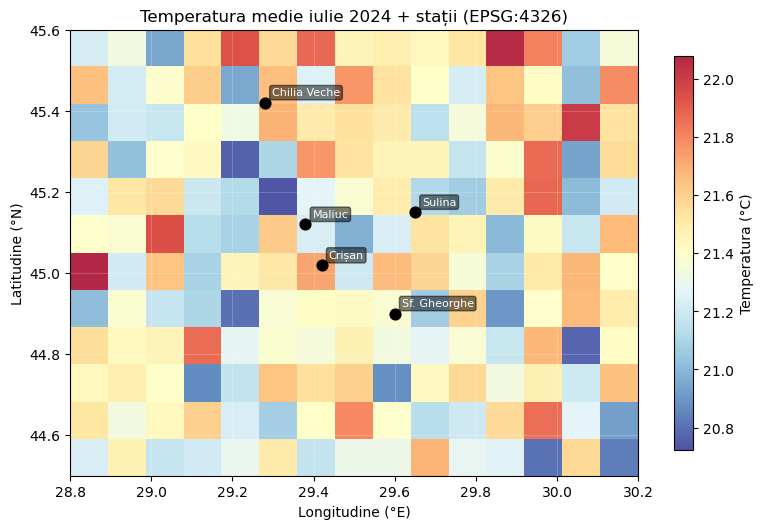


→ Raster și vector în ACELAȘI CRS (EPSG:4326) → se suprapun corect!


In [ ]:
# ── Hartă finală: temperatură + stații vectoriale ─────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Raster: GeoTIFF ca fundal
tif_2d = tif.squeeze()   # elimină dimensiunea 'band' → (y, x)
im = ax.imshow(tif_2d.values,
               extent=[float(lons[0]), float(lons[-1]),
                        float(lats[0]), float(lats[-1])],
               cmap='RdYlBu_r', origin='lower', alpha=0.85)
plt.colorbar(im, ax=ax, label='Temperatura (°C)', shrink=0.7)

# Vector: stații ca puncte deasupra rasterului
for _, row in gdf.iterrows():
    ax.scatter(row.geometry.x, row.geometry.y,
               color='black', s=60, zorder=5)
    ax.annotate(row['name'],
                (row.geometry.x, row.geometry.y),
                textcoords='offset points', xytext=(5, 5), fontsize=8,
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

ax.set_title('Temperatura medie iulie 2024 + stații (EPSG:4326)')
ax.set_xlabel('Longitudine (°E)')
ax.set_ylabel('Latitudine (°N)')
ax.grid(alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

print('\n→ Raster și vector în ACELAȘI CRS (EPSG:4326) → se suprapun corect!')

## 3.4 Zarr

**Zarr** nu e un fișier — e un **folder cu sub-foldere**. Array-ul e tăiat în bucăți mici (**chunks**) stocate separat, fiecare comprimat independent.

```
temperatura_delta_2024.zarr/
├── .zmetadata          ← metadate globale
├── t2m/
│   ├── .zarray         ← shape, dtype, chunks
│   ├── 0.0.0           ← chunk time[0:30], lat[:], lon[:]
│   ├── 1.0.0           ← chunk time[30:60], ...
│   └── ...
└── time/ lat/ lon/     ← coordonate
```

**De ce Zarr?**
- Citire **lazy și paralelă** — încarci doar chunk-urile de care ai nevoie
- Ideal pentru date mari pe **cloud** (S3, GCS, Azure Blob)
- API identic cu NetCDF prin xarray — codul nu se schimbă

In [ ]:
# ── Zarr — scriere și citire ──────────────────────────────────────────
# Folosim același Dataset `ds` creat la secțiunea NetCDF

# Scriere — API identic cu to_netcdf, dar produce un folder
ds.to_zarr('temperatura_delta_2024.zarr', mode='w')
print('✓ Salvat: temperatura_delta_2024.zarr/ (folder, nu fișier)')

# Citire standard — lazy, ca NetCDF
ds_z = xr.open_zarr('temperatura_delta_2024.zarr')
print('\nDataset citit din Zarr:')
print(ds_z)

# ── Chunks — avantajul principal ──────────────────────────────────────
# Chunk = bucată de date citită odată din disk/cloud
# Citire cu chunk-uri explicit: încarcă câte 30 de zile
ds_zc = xr.open_zarr('temperatura_delta_2024.zarr', chunks={'time': 30})
print(f'\nChunk-uri t2m: {ds_zc["t2m"].chunks}')
print('→ Operațiile pe ds_zc sunt lazy până la .compute() sau .values')

# ── Selectare și calcul — identic cu NetCDF ───────────────────────────
t_aug_zarr = ds_z['t2m'].sel(time='2024-08').mean(dim=['lat', 'lon'])
print(f'\nT medie august (din Zarr): {float(t_aug_zarr.mean()):.2f}°C')

# ── Comparație NetCDF vs Zarr ─────────────────────────────────────────
import os, pathlib

size_nc  = os.path.getsize('temperatura_delta_2024.nc') / 1024
size_zarr = sum(
    f.stat().st_size for f in pathlib.Path('temperatura_delta_2024.zarr').rglob('*') if f.is_file()
) / 1024

print(f'\nDimensiune pe disk:')
print(f'  NetCDF : {size_nc:,.0f} KB  (un singur fișier)')
print(f'  Zarr   : {size_zarr:,.0f} KB  (folder cu {len(list(pathlib.Path("temperatura_delta_2024.zarr").rglob("*")))} obiecte)')

✓ Salvat: temperatura_delta_2024.zarr/ (folder, nu fișier)

Dataset citit din Zarr:
<xarray.Dataset> Size: 267kB
Dimensions:  (time: 366, lat: 12, lon: 15)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * lat      (lat) float64 96B 44.5 44.6 44.7 44.8 44.9 ... 45.3 45.4 45.5 45.6
  * lon      (lon) float64 120B 28.8 28.9 29.0 29.1 29.2 ... 29.9 30.0 30.1 30.2
Data variables:
    t2m      (time, lat, lon) float32 264kB dask.array<chunksize=(183, 12, 15), meta=np.ndarray>

Chunk-uri t2m: ((30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 6), (12,), (15,))
→ Operațiile pe ds_zc sunt lazy până la .compute() sau .values

T medie august (din Zarr): 16.26°C

Dimensiune pe disk:
  NetCDF : 268 KB  (un singur fișier)
  Zarr   : 241 KB  (folder cu 22 obiecte)


---
## Rezumat — ce format alegem?

| Format | Bibliotecă | Fișier/Folder | Cu timp? | Cu CRS? | Când |
|:---|:---|:---:|:---:|:---:|:---|
| **GeoJSON** | `geopandas` | fișier `.geojson` | ✗ | ✓ | Puncte/linii/poligoane mici, web |
| **GPKG** | `geopandas` | fișier `.gpkg` | ✗ | ✓ | Vector local, mai multe straturi |
| **NetCDF** | `xarray` | fișier `.nc` | ✓ | parțial | Climate grids: ERA5, CMIP6 |
| **GeoTIFF** | `rioxarray` | fișier `.tif` | ✗ | ✓ | Un câmp 2D, compatibil GIS |
| **Zarr** | `xarray` | **folder** `.zarr/` | ✓ | parțial | Date mari, cloud, procesare chunked |

> **Regulă practică:**  
> — Date vectoriale → **GPKG**  
> — Serie temporală climatic grid → **NetCDF** (mic–mediu) sau **Zarr** (mare/cloud)  
> — O singură hartă raster → **GeoTIFF**

---
# Etapa 4 · Vizualizare — matplotlib + Plotly interactiv
*(65–75 min)*

**Matplotlib** produce figuri statice (PNG, PDF) — pentru publicații și rapoarte.  
**Plotly** produce grafice HTML interactive cu hover, zoom și animații — pentru explorare și prezentări.

| Bibliotecă | Output | Interactiv? | Cel mai bun pentru |
|:---|:---:|:---:|:---|
| `matplotlib` | PNG / PDF | ✗ | Publicații, rapoarte, figuri finale |
| `plotly.express` | HTML widget | ✓ | Explorare date, prezentări, dashboards |

Vom folosi **aceleași date** create în etapele anterioare: `ds` (xarray), `gdf` (geopandas), `lats`, `lons` (numpy).

## 4.1 Matplotlib — anatomia unei figuri

Matplotlib e biblioteca de bază pentru grafice statice în Python.

```
fig, axes = plt.subplots(nrows, ncols)
│             │
│             └── Axes[]  — fiecare subplot are propriul sistem de coordonate
└── Figure    — suprafața pe care se desenează (conține toate subplot-urile)
```

`ax.plot()` / `ax.bar()` / `ax.imshow()` → adaugă date pe Axes.  
`ax.set_title/xlabel/ylabel/legend/grid` → personalizează aspectul.

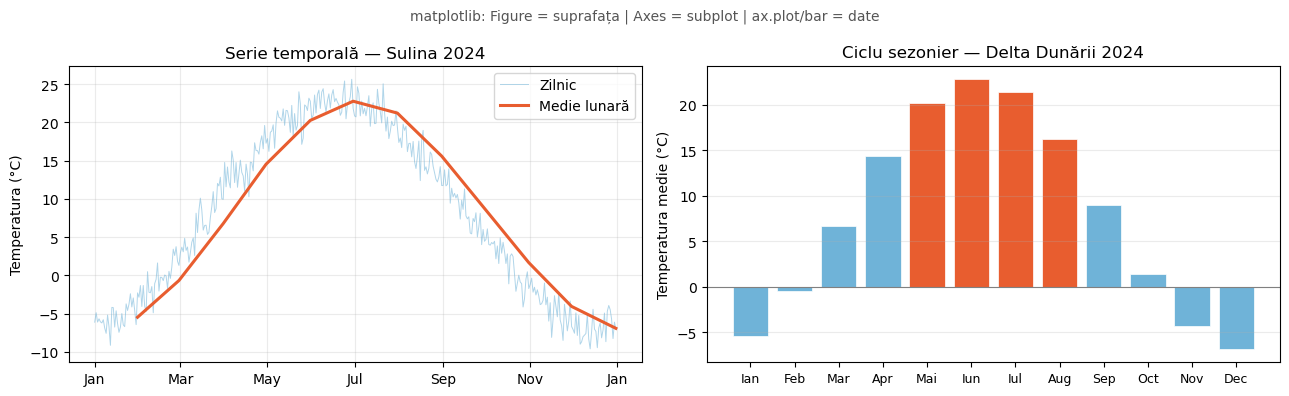

In [ ]:
from matplotlib.dates import DateFormatter

# ── Figure / Axes — componentele unui grafic matplotlib ──────────────
# Figure = suprafața pe care se desenează
# Axes   = un subplot cu propriul sistem de coordonate
# plt.subplots(nrows, ncols) → returnează (fig, array_of_axes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Subplot stânga: serie temporală ───────────────────────────────────
t_sulina_s = ds['t2m'].sel(lat=45.1, lon=29.6, method='nearest').to_pandas()
t_lunar_s  = t_sulina_s.resample('ME').mean()

axes[0].plot(t_sulina_s.index, t_sulina_s.values,
             color='#6FB3D8', linewidth=0.7, alpha=0.55, label='Zilnic')
axes[0].plot(t_lunar_s.index, t_lunar_s.values,
             color='#E85D2F', linewidth=2.2, label='Medie lunară')
axes[0].set_title('Serie temporală — Sulina 2024')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].xaxis.set_major_formatter(DateFormatter('%b'))
axes[0].legend()
axes[0].grid(alpha=0.25)

# ── Subplot dreapta: bare sezoniere ───────────────────────────────────
luni_ro_bar = ['Ian','Feb','Mar','Apr','Mai','Iun',
               'Iul','Aug','Sep','Oct','Nov','Dec']
t_lunare_s  = ds['t2m'].mean(dim=['lat','lon']).resample(time='1ME').mean().to_pandas()
culori_bar  = ['#6FB3D8' if v < 15 else '#E85D2F' for v in t_lunare_s.values]

axes[1].bar(range(12), t_lunare_s.values, color=culori_bar,
            edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(luni_ro_bar, fontsize=9)
axes[1].set_title('Ciclu sezonier — Delta Dunării 2024')
axes[1].set_ylabel('Temperatura medie (°C)')
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.25)

fig.suptitle('matplotlib: Figure = suprafața | Axes = subplot | ax.plot/bar = date',
             fontsize=10, color='#555')
plt.tight_layout()
plt.show()

## 4.2 Plotly Express — serie temporală interactivă

**`plotly.express`** (alias `px`) generează grafice interactive cu o singură linie de cod.  
Outputul e un widget HTML embedded în notebook — hover, zoom și pan sunt incluse automat.

In [ ]:
import plotly.express as px
import pandas as pd

# ── xarray → pandas DataFrame → Plotly ───────────────────────────────
# Plotly lucrează cu DataFrames — convertim DataArray-ul xarray

t_sulina_s = ds['t2m'].sel(lat=45.1, lon=29.6, method='nearest').to_pandas()

df_ts = pd.DataFrame({
    'data'     : t_sulina_s.index,
    'zilnic'   : t_sulina_s.values,
    'medie_7z' : t_sulina_s.rolling(7, center=True).mean().values,
})

# ── Grafic interactiv cu hover unificat ───────────────────────────────
fig_ts = px.line(
    df_ts, x='data', y=['zilnic', 'medie_7z'],
    title='Temperatura la Sulina — 2024 (hover pentru valori exacte)',
    labels={'data': 'Dată', 'value': '°C', 'variable': 'Serie'},
    color_discrete_map={'zilnic': '#6FB3D8', 'medie_7z': '#E85D2F'},
)
fig_ts.update_traces(selector=dict(name='zilnic'),
                     line=dict(width=0.8), opacity=0.5)
fig_ts.update_traces(selector=dict(name='medie_7z'),
                     line=dict(width=2.5))
fig_ts.update_layout(
    hovermode='x unified',
    legend=dict(orientation='h', y=1.02),
    margin=dict(t=60),
)
fig_ts.show()
print('→ Hover pe orice punct | Zoom cu scroll sau drag | Dublu-click pentru reset')

→ Hover pe orice punct | Zoom cu scroll sau drag | Dublu-click pentru reset


## 4.3 Heatmap interactiv — date raster

`px.imshow` afișează un array 2D ca heatmap cu hover pe fiecare pixel.  
Cu `animation_frame=0` pe un array 3D (luni × lat × lon) obținem o animație cu slider.

In [ ]:
# ── px.imshow — heatmap interactiv pentru date raster ─────────────────
# Nota: folosim ds direct (cu lat/lon), nu t_iulie care a fost redenumit

t_iulie_plot = ds['t2m'].sel(time='2024-07').mean(dim='time')   # (lat, lon)

fig_raster = px.imshow(
    t_iulie_plot.values,
    x=lons.tolist(),
    y=lats.tolist(),
    color_continuous_scale='RdYlBu_r',
    origin='lower',
    aspect='auto',
    title='Temperatura medie iulie 2024 — heatmap interactiv (hover pentru valori)',
    labels={'x': 'Longitudine (°E)', 'y': 'Latitudine (°N)', 'color': '°C'},
)
fig_raster.update_layout(coloraxis_colorbar=dict(title='°C'))
fig_raster.show()

# ── Animație: ciclu anual luna cu luna ────────────────────────────────
t_monthly   = ds['t2m'].resample(time='1ME').mean()   # (12, lat, lon)
luni_ro_anim = ['Ian','Feb','Mar','Apr','Mai','Iun',
                'Iul','Aug','Sep','Oct','Nov','Dec']

fig_anim = px.imshow(
    t_monthly.values,                # (12, lat, lon)
    x=lons.tolist(), y=lats.tolist(),
    animation_frame=0,               # prima dimensiune = luni
    color_continuous_scale='RdYlBu_r',
    origin='lower', aspect='auto',
    zmin=-5, zmax=30,
    title='Ciclu anual de temperaturi — animație (▶ Play sau slider)',
    labels={'x': 'Lon (°E)', 'y': 'Lat (°N)', 'color': '°C'},
)
for i, lbl in enumerate(luni_ro_anim):
    if i < len(fig_anim.frames):
        fig_anim.frames[i].name = lbl
fig_anim.update_layout(sliders=[dict(currentvalue=dict(prefix='Luna: '))])
fig_anim.show()
print('→ ▶ Play pentru animație automată | trageți slider-ul pentru navigare manuală')

→ ▶ Play pentru animație automată | trageți slider-ul pentru navigare manuală


## 4.4 Hartă interactivă — date vectoriale

`px.scatter_mapbox` plasează puncte vectoriale pe o hartă tile (OpenStreetMap, fără API key).  
Dimensiunea și culoarea sunt mapate pe **atribute** din GeoDataFrame.

In [ ]:
# ── px.scatter_mapbox — stații pe hartă interactivă ──────────────────
# mapbox_style='open-street-map' nu necesită API key

gdf_plot = gdf.copy()
gdf_plot['lat'] = gdf.geometry.y
gdf_plot['lon'] = gdf.geometry.x

fig_map = px.scatter_mapbox(
    gdf_plot,
    lat='lat', lon='lon',
    color='temp_iulie',
    size='populatie',
    hover_name='name',
    hover_data={'tip': True, 'populatie': True, 'temp_iulie': True,
                'lat': False, 'lon': False},
    color_continuous_scale='RdYlBu_r',
    size_max=30,
    zoom=8,
    center=dict(lat=45.1, lon=29.5),
    title='Stații de monitorizare — Delta Dunării (hover + zoom)',
    labels={'temp_iulie': 'T iulie (°C)', 'populatie': 'Populație'},
    mapbox_style='open-street-map',
)
fig_map.update_layout(margin=dict(t=60))
fig_map.show()
print('→ Scroll pentru zoom | Drag pentru pan | Hover pentru detalii stație')

→ Scroll pentru zoom | Drag pentru pan | Hover pentru detalii stație


---
# Exercițiu — 10 min

Folosind datele create în acest notebook:

1. **Funcție**: scrie o funcție `temp_categorie(t)` care returnează `'îngheț'` (t < 0), `'rece'` (0–10), `'moderat'` (10–20), `'cald'` (≥ 20).

2. **NumPy**: calculează câte zile din 2024 au temperatura medie spațială > 20°C (folosind `ds['t2m'].mean(dim=['lat','lon'])`).

3. **CRS**: convertește stația `Crișan` din EPSG:4326 în EPSG:32635 folosind `pyproj.Transformer`.

4. **NetCDF**: salvează temperatura medie din **august** ca fișier NetCDF: `temp_august_2024.nc`.

5. **Plotly**: creează un grafic `px.bar` cu temperatura medie lunară pentru toate cele 5 stații (hint: iterează prin `gdf` și construiește un DataFrame cu coloanele `statie`, `luna`, `temp`).

---
```python
# Hint 1
def temp_categorie(t):
    if t < 0:   return 'îngheț'
    if t < 10:  return 'rece'
    if t < 20:  return 'moderat'
    return 'cald'

# Hint 2
ts_zilnic = ds['t2m'].mean(dim=['lat', 'lon'])
n_zile = int((ts_zilnic > 20).sum())
print(f'Zile > 20°C: {n_zile}')

# Hint 3
t = Transformer.from_crs('EPSG:4326', 'EPSG:32635', always_xy=True)
x, y = t.transform(29.42, 45.02)   # lon, lat
print(f'Crișan UTM: E={x:.0f} m, N={y:.0f} m')

# Hint 4
ds['t2m'].sel(time='2024-08').mean(dim='time') \
         .to_dataset(name='t2m') \
         .to_netcdf('temp_august_2024.nc')

# Hint 5 — Plotly bar per stație
import plotly.express as px, pandas as pd
luni_ro = ['Ian','Feb','Mar','Apr','Mai','Iun','Iul','Aug','Sep','Oct','Nov','Dec']
rows = []
for _, row in gdf.iterrows():
    vals = ds['t2m'].sel(lat=row.geometry.y, lon=row.geometry.x, method='nearest') \
                    .resample(time='1ME').mean().values
    for i, v in enumerate(vals):
        rows.append({'statie': row['name'], 'luna': luni_ro[i], 'temp': float(v)})
px.bar(pd.DataFrame(rows), x='luna', y='temp', color='statie',
       barmode='group', title='Ciclu sezonier per stație').show()
```